In [250]:
import pandas as pd
import numpy as np
import re

## Charger le CSV

In [251]:
url= "Pokemon_dataset.csv"
# df = pd.read_csv(url, sep=";", encoding="utf-8")
df = pd.read_csv(url, sep=";", encoding="utf-8", index_col=0)
df

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
#,635,606,58,479,61,560,317,442,690,411,...,419,113,554,16,639,65,98,250,390,94
Name,hydreigon,Beheeyem,Growlithe,RotomWash Rotom,Poliwhirl,SCRAFTY,Swalot,Spiritomb,skrelp,Bastiodon,...,FLOATZEL,CHANSEY,darumaka,Pidgey,Terrakion,ALAKAZAMMEGA ALAKAZAM,KRABBY,Ho-oh,chimchar,gengarmega gengar
Total,600,485,350,520,385,488,467,485,320,495,...,495,450,315,251,580,590,325,680,309,600
HP,92.0,75.0,55.0,50.0,65.0,NaN,100.0,50.0,50.0,60.0,...,85.0,250.0,70.0,40.0,91.0,55.0,30.0,106.0,NaN,60.0
Attack,105,75,70,65,65,90,73,92,60,52,...,105,5,90,45,129,NaN,105,130,58,NaN
Defense % of Attack,85.7143,100.0,64.2857,164.6154,100.0,127.7778,113.6986,117.3913,100.0,323.0769,...,52.381,100.0,50.0,88.8889,69.7674,130.0,85.7143,69.2308,75.8621,123.0769
Sp. Atk / Sp. Def,125 / 90,125 / 95,70 / 50,105 / 107,50 / 50,45 / 115,73 / 83,92 / 108,60 / 60,47 / 138,...,85 / 50,35 / 105,15 / 45,35 / 35,72 / 90,175 / 95,25 / 25,110 / 154,58 / 44,170 / 95
Speed,98.0,40.0,60.0,86.0,90.0,58.0,55.0,35.0,30.0,30.0,...,115.0,50.0,50.0,56.0,108.0,150.0,50.0,90.0,61.0,130.0
Generation,5.0,5.0,1.0,4.0,1.0,5.0,3.0,4.0,6.0,4.0,...,4.0,NaN,5.0,1.0,5.0,1.0,1.0,2.0,NaN,1.0
Legendary,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False


## Transposee du dataframe

In [252]:
df = df.T
# df.columns = df.iloc[0]
# df = df.iloc[1:].reset_index(drop=True)
df

,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Speed,Generation,Legendary,Types
0,635,hydreigon,600,92.0,105,85.7143,125 / 90,98.0,5.0,False,"Dark, Dragon"
1,606,Beheeyem,485,75.0,75,100.0,125 / 95,40.0,5.0,False,"Psychic,"
2,58,Growlithe,350,55.0,70,64.2857,70 / 50,60.0,1.0,False,"Fire,"
3,479,RotomWash Rotom,520,50.0,65,164.6154,105 / 107,86.0,4.0,False,"Electric, Water"
4,61,Poliwhirl,385,65.0,65,100.0,50 / 50,90.0,1.0,False,"Water,"
...,...,...,...,...,...,...,...,...,...,...,...
795,65,ALAKAZAMMEGA ALAKAZAM,590,55.0,NaN,130.0,175 / 95,150.0,1.0,False,"Psychic,"
796,98,KRABBY,325,30.0,105,85.7143,25 / 25,50.0,1.0,False,"Water,"
797,250,Ho-oh,680,106.0,130,69.2308,110 / 154,90.0,2.0,True,"Fire, Flying"
798,390,chimchar,309,NaN,58,75.8621,58 / 44,61.0,NaN,False,"Fire,"


## Fonction pour voir pokemon par id

In [253]:
def afficher_pokemon(df, num = []):
    display(df[df['#'].isin(num)])

## Fix les colonnes numeriques

In [254]:
# ATTENTION : avec cette fonction on va enlever le '-' ce qui va nous donner en quelques sortes
# la valeur absolue des nombres concernés
def regex_garder_numerique(df, columns=[]):
    for name in columns:
        df[name] = df[name].str.replace(r"[^0-9.]", "", regex=True)
    return df

df = regex_garder_numerique(df, ["HP", "Attack", "Defense % of Attack", "Speed", "Generation"])

## Changer les types des colonnes

In [255]:
colonnes_num = [
    "#", "Total", "HP", "Attack",
    "Defense % of Attack", "Speed", "Generation"
]

for col in colonnes_num:
    df[col] = pd.to_numeric(df[col], errors="raise")
    # erreurs = df[pd.to_numeric(df[col], errors="coerce").isna()][col]
    # if not erreurs.empty:
    #     print(f"\nColonne : {col}")
    #     print(erreurs.unique())

In [256]:
df.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #                    800 non-null    int64  
 1   Name                 800 non-null    str    
 2   Total                800 non-null    int64  
 3   HP                   773 non-null    float64
 4   Attack               775 non-null    float64
 5   Defense % of Attack  800 non-null    float64
 6   Sp. Atk / Sp. Def    800 non-null    str    
 7   Speed                757 non-null    float64
 8   Generation           761 non-null    float64
 9   Legendary            800 non-null    str    
 10  Types                800 non-null    str    
dtypes: float64(5), int64(2), str(4)
memory usage: 107.3+ KB


## Trier par # et fix "Generation"

In [257]:
df.sort_values("#", inplace=True)
df["Generation"] = pd.to_numeric(df["Generation"].ffill().bfill())
df

,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Speed,Generation,Legendary,Types
374,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,45.0,1.0,False,"Grass, Poison"
729,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,60.0,1.0,False,"Grass, Poison"
151,3,venusaur,525,80.0,82.0,101.2195,100 / 100,80.0,1.0,False,"Grass, Poison"
325,3,VenusaurMega Venusaur,625,80.0,100.0,123.0000,122 / 120,80.0,1.0,False,"Grass, Poison"
672,4,CHARMANDER,309,39.0,52.0,82.6923,60 / 50,65.0,1.0,False,"Fire,"
...,...,...,...,...,...,...,...,...,...,...,...
38,719,DiancieMega Diancie,700,50.0,160.0,68.7500,160 / 110,110.0,6.0,True,"Rock, Fairy"
72,719,DIANCIE,600,50.0,100.0,150.0000,100 / 150,50.0,6.0,True,"Rock, Fairy"
156,720,HoopaHoopa Unbound,680,80.0,160.0,37.5000,170 / 130,80.0,6.0,True,"Psychic, Dark"
718,720,HoopaHoopa Confined,600,80.0,110.0,54.5455,150 / 130,70.0,6.0,True,"Psychic, Ghost"


## Gerer Noms

In [258]:
df["Name"] = df["Name"].str.title()
df

,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Speed,Generation,Legendary,Types
374,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,45.0,1.0,False,"Grass, Poison"
729,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,60.0,1.0,False,"Grass, Poison"
151,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,80.0,1.0,False,"Grass, Poison"
325,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,80.0,1.0,False,"Grass, Poison"
672,4,Charmander,309,39.0,52.0,82.6923,60 / 50,65.0,1.0,False,"Fire,"
...,...,...,...,...,...,...,...,...,...,...,...
38,719,Dianciemega Diancie,700,50.0,160.0,68.7500,160 / 110,110.0,6.0,True,"Rock, Fairy"
72,719,Diancie,600,50.0,100.0,150.0000,100 / 150,50.0,6.0,True,"Rock, Fairy"
156,720,Hoopahoopa Unbound,680,80.0,160.0,37.5000,170 / 130,80.0,6.0,True,"Psychic, Dark"
718,720,Hoopahoopa Confined,600,80.0,110.0,54.5455,150 / 130,70.0,6.0,True,"Psychic, Ghost"


## Supprimer doublons

In [259]:
print(df.shape)
df = df.drop_duplicates()
print(df.shape)

(800, 11)
(800, 11)


In [260]:
df

,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Speed,Generation,Legendary,Types
374,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,45.0,1.0,False,"Grass, Poison"
729,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,60.0,1.0,False,"Grass, Poison"
151,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,80.0,1.0,False,"Grass, Poison"
325,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,80.0,1.0,False,"Grass, Poison"
672,4,Charmander,309,39.0,52.0,82.6923,60 / 50,65.0,1.0,False,"Fire,"
...,...,...,...,...,...,...,...,...,...,...,...
38,719,Dianciemega Diancie,700,50.0,160.0,68.7500,160 / 110,110.0,6.0,True,"Rock, Fairy"
72,719,Diancie,600,50.0,100.0,150.0000,100 / 150,50.0,6.0,True,"Rock, Fairy"
156,720,Hoopahoopa Unbound,680,80.0,160.0,37.5000,170 / 130,80.0,6.0,True,"Psychic, Dark"
718,720,Hoopahoopa Confined,600,80.0,110.0,54.5455,150 / 130,70.0,6.0,True,"Psychic, Ghost"


## Reset index

In [261]:
df = df.reset_index(drop=True)
df.columns.name = "index"
df.head()

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Speed,Generation,Legendary,Types
0,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,45.0,1.0,False,"Grass, Poison"
1,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,60.0,1.0,False,"Grass, Poison"
2,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,80.0,1.0,False,"Grass, Poison"
3,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,80.0,1.0,False,"Grass, Poison"
4,4,Charmander,309,39.0,52.0,82.6923,60 / 50,65.0,1.0,False,"Fire,"


## Split Sp. Atk / Sp. Def

Cette facon de faire va poser un problème car on ne gère pas les lignes qui ont 3 valeurs dans Sp. Atk / Sp. Def. Cela va nous conduire ensuite a les remplacer par des nan ce qui va apauvrir notre base de données

In [262]:
# split_cols = df['Sp. Atk / Sp. Def'].astype(str).str.split('/', n=1, expand=True)
# df['Sp. Atk'] = split_cols[0].str.strip()
# df['Sp. Def'] = split_cols[1].str.strip()

# df.drop(columns=['Sp. Atk / Sp. Def'], inplace=True)
# df.head()

### Bonne facon de faire en changeant a la main les deux lignes problématiques

In [263]:
# # Pour trouver les lignes problématiques
# split = df["Sp. Atk / Sp. Def"].str.split("/", expand=True)
# print(split.shape)

In [264]:
# # Si le nombre de colonnes est différent de 2, jecherche les valeurs anormales :
# df[df["Sp. Atk / Sp. Def"].str.count("/") != 1]["Sp. Atk / Sp. Def"]
# erreurs = df[df["Sp. Atk / Sp. Def"].str.count("/") != 1]
# print(erreurs)


In [265]:
# # faut corriger d'abord
# df.loc[789, "Sp. Atk / Sp. Def"] = "44 / 46"
# df.loc[115 , "Sp. Atk / Sp. Def"] = "35 / 110" 
# split = df["Sp. Atk / Sp. Def"].str.split("/", expand=True)

# print(split.shape)
# print(split.columns)
# nb = df["Sp. Atk / Sp. Def"].str.split("/").str.len()

# print(df.loc[nb != 2, "Sp. Atk / Sp. Def"])

In [266]:
# # nettoyage de données, la meilleure pratique est de les séparer en deux colonnes numériques.
# df[["Sp. Atk", "Sp. Def"]] = df["Sp. Atk / Sp. Def"].str.split("/", expand=True)
# #J' enleve les espaces et convertir en nombres :
# df["Sp. Def"] = pd.to_numeric(df["Sp. Def"].str.strip())
# df["Sp. Atk"] = pd.to_numeric(df["Sp. Atk"].str.strip())

# # Ensuite, je supprime l'ancienne colonne :
# df = df.drop(columns=["Sp. Atk / Sp. Def"])
# df.head()

In [267]:
# afficher_pokemon(df, [107,713])

### Autre bonne facon de faire avec la regex

In [268]:
df["Sp. Atk / Sp. Def"] = (
    df["Sp. Atk / Sp. Def"]
    .str.replace("//", "/", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

df["Sp. Atk / Sp. Def"] = df["Sp. Atk / Sp. Def"].str.replace(
    r"^\s*(\d+)\s*/\s*(\d+)\s*/\s*\d+\s*$",
    r"\1 / \2",
    regex=True
)

df_sp_atk = df["Sp. Atk / Sp. Def"].str.split(" / ", expand=True)[0]
df_sp_def = df["Sp. Atk / Sp. Def"].str.split(" / ", expand=True)[1]

index_sp_atk_def = df.columns.get_loc("Sp. Atk / Sp. Def")

df.insert(index_sp_atk_def + 1, "Sp. Atk", df_sp_atk)
df.insert(index_sp_atk_def + 2, "Sp. Def", df_sp_def)
df.head()

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
0,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,65,65,45.0,1.0,False,"Grass, Poison"
1,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,80,80,60.0,1.0,False,"Grass, Poison"
2,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,100,100,80.0,1.0,False,"Grass, Poison"
3,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,122,120,80.0,1.0,False,"Grass, Poison"
4,4,Charmander,309,39.0,52.0,82.6923,60 / 50,60,50,65.0,1.0,False,"Fire,"


In [269]:
afficher_pokemon(df, [107,713])

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
115,107,Hitmonchan,455,50.0,105.0,75.2381,35 / 110,35,110,76.0,1.0,False,"Fighting,"
789,713,Avalugg,514,95.0,117.0,157.2650,44 / 46,44,46,28.0,6.0,False,"Ice,"


## Fix Defense %

In [270]:
df.head()

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types
0,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,65,65,45.0,1.0,False,"Grass, Poison"
1,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,80,80,60.0,1.0,False,"Grass, Poison"
2,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,100,100,80.0,1.0,False,"Grass, Poison"
3,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,122,120,80.0,1.0,False,"Grass, Poison"
4,4,Charmander,309,39.0,52.0,82.6923,60 / 50,60,50,65.0,1.0,False,"Fire,"


In [271]:
df["Defense"] = (
    df["Defense % of Attack"] * df["Attack"] / 100
).round()
df.head()

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
0,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,65,65,45.0,1.0,False,"Grass, Poison",49.0
1,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,80,80,60.0,1.0,False,"Grass, Poison",63.0
2,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,100,100,80.0,1.0,False,"Grass, Poison",83.0
3,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,122,120,80.0,1.0,False,"Grass, Poison",123.0
4,4,Charmander,309,39.0,52.0,82.6923,60 / 50,60,50,65.0,1.0,False,"Fire,",43.0


## Valeurs manquantes

In [272]:
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                     27
Attack                 25
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                  43
Generation              0
Legendary               0
Types                   0
Defense                25
dtype: int64

In [273]:
df["Sp. Atk"] = df["Sp. Atk"].astype(float)
df["Sp. Def"] = df["Sp. Def"].astype(float)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #                    800 non-null    int64  
 1   Name                 800 non-null    str    
 2   Total                800 non-null    int64  
 3   HP                   773 non-null    float64
 4   Attack               775 non-null    float64
 5   Defense % of Attack  800 non-null    float64
 6   Sp. Atk / Sp. Def    800 non-null    str    
 7   Sp. Atk              800 non-null    float64
 8   Sp. Def              800 non-null    float64
 9   Speed                757 non-null    float64
 10  Generation           800 non-null    float64
 11  Legendary            800 non-null    str    
 12  Types                800 non-null    str    
 13  Defense              775 non-null    float64
dtypes: float64(8), int64(2), str(4)
memory usage: 87.6 KB


### HP manquants

In [274]:
display(df[(df["HP"] > df["Total"]) | (df["Attack"] > df["Total"]) | (df["Speed"] > df["Total"] ) | (df["Sp. Atk"] > df["Total"] ) | (df["Sp. Def"] > df["Total"] )])
df.loc[df["HP"] > df["Total"], "HP"] = np.nan

display(df[(df["HP"] > df["Total"]) | (df["Attack"] > df["Total"]) | (df["Speed"] > df["Total"]) | (df["Sp. Atk"] > df["Total"] ) | (df["Sp. Def"] > df["Total"] )])


#display(df.loc[df["Id"] == 15])
print(df.isna().sum())

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
18,15,Beedrill,395,15925.0,90.0,44.4444,45 / 80,45.0,80.0,75.0,1.0,False,"Bug, Poison",40.0
374,342,Crawdaunt,468,15435.0,120.0,70.8333,90 / 55,90.0,55.0,55.0,3.0,False,"Water, Dark",85.0
411,375,Metang,420,14700.0,75.0,133.3333,55 / 80,55.0,80.0,50.0,3.0,False,"Steel, Psychic",100.0
536,479,Rotomfan Rotom,520,12250.0,65.0,164.6154,105 / 107,105.0,107.0,NaN,4.0,False,"Electric, Flying",107.0
643,582,Vanillite,305,8820.0,50.0,100.0000,65 / 60,65.0,60.0,NaN,5.0,False,"Ice,",50.0
645,584,Vanilluxe,535,17395.0,95.0,89.4737,110 / 95,110.0,95.0,79.0,5.0,False,"Ice,",85.0


index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense


index
#                       0
Name                    0
Total                   0
HP                     33
Attack                 25
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                  43
Generation              0
Legendary               0
Types                   0
Defense                25
dtype: int64


In [275]:
# Cas deja géré plus haut avec la regex qui enleve les "-"
# display(df.head())
# colonnes = ["Total", "HP", "Defense % of Attack", "Sp. Atk", "Sp. Def", "Speed"]
# display(df[(df[colonnes] < 0).any(axis=1)])
# df["HP"] = df["HP"].abs() # pour mettre la colonne en valeur absolue
# df

In [276]:
df.fillna({
    "HP": df["Total"] - (df["Attack"] + df["Defense"] + df["Sp. Atk"] + df["Sp. Def"] + df["Speed"] )
}, inplace= True)
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                      5
Attack                 25
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                  43
Generation              0
Legendary               0
Types                   0
Defense                25
dtype: int64

### Speed manquants

In [277]:
df.fillna({
    "Speed": df["Total"] - (df["Attack"] + df["Defense"] + df["Sp. Atk"] + df["Sp. Def"] + df["HP"] )
}, inplace= True)
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                      5
Attack                 25
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                   4
Generation              0
Legendary               0
Types                   0
Defense                25
dtype: int64

In [278]:
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                      5
Attack                 25
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                   4
Generation              0
Legendary               0
Types                   0
Defense                25
dtype: int64

### Cas de plusieurs nan par ligne (sauf les Attack Defense qui manquent)

In [279]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

def calculer_statistiques_multiple_nan(df, stats, df_ratio):
    masque = df[stats].isna().sum(axis=1) > 1
    print("========== masque ==========")
    print(masque)
    reste = df.loc[masque, "Total"] - df.loc[masque, stats].sum(axis=1)
    print("========== reste ==========")
    print(reste)
        
    ratios = df_ratio.loc[df.loc[masque, "Types"]]
    print("========== ratios ==========")
    print(ratios)

    ratios.index = df.loc[masque].index
    print("========== ratios ==========")
    print(ratios)

    ratios_nan = ratios.where(df.loc[masque, stats].isna())
    print("========== ratios_nan ==========")
    print(ratios_nan)

    nouveaux_ratios = ratios_nan.div(ratios_nan.sum(axis=1), axis=0)
    print("========== nouveaux_ratios ==========")
    print(nouveaux_ratios)
    
    nouvelles_stats = nouveaux_ratios.mul(reste, axis=0)
    print("========== nouvelles_stats ==========")
    print(nouvelles_stats)

    df.loc[masque, stats] = df.loc[masque, stats].fillna(nouvelles_stats.round())

    return df

moyennes_stats = df.groupby(["Types"])[stats].mean()
moyennes_total = df.groupby(["Types"])["Total"].mean()

print(moyennes_stats)
print(moyennes_total)

df_ratio = pd.DataFrame(index=moyennes_stats.index)
df_ratio["HP"] = moyennes_stats["HP"] / moyennes_total
df_ratio["Attack + Defense"] = ((moyennes_stats["Attack"] + moyennes_stats["Defense"]) / moyennes_total)
df_ratio["Sp. Atk"] = moyennes_stats["Sp. Atk"] / moyennes_total
df_ratio["Sp. Def"] = moyennes_stats["Sp. Def"] / moyennes_total
df_ratio["Speed"] = moyennes_stats["Speed"] / moyennes_total

print(df_ratio)

df["Attack + Defense"] = (df["Attack"] + df["Defense"]).where(df["Attack"].notna() & df["Defense"].notna())
new_stats = ["HP", "Attack + Defense", "Sp. Atk", "Sp. Def", "Speed"]

df = calculer_statistiques_multiple_nan(df, new_stats, df_ratio)

index                  HP      Attack     Defense     Sp. Atk     Sp. Def  \
Types                                                                       
Bug,            53.058824   50.352941   55.411765   39.294118   43.647059   
Bug, Electric   60.000000   62.000000   55.000000   77.000000   55.000000   
Bug, Fighting   80.000000  155.000000   95.000000   40.000000  100.000000   
Bug, Fire       70.000000   72.500000   60.000000   92.500000   80.000000   
Bug, Flying     63.000000   70.142857   61.571429   72.857143   69.071429   
...                   ...         ...         ...         ...         ...   
Water, Ice      90.000000   83.333333  113.333333   80.000000   78.333333   
Water, Poison   61.666667   68.333333   58.333333   61.666667   91.666667   
Water, Psychic  87.000000   73.000000  104.000000   94.000000   79.000000   
Water, Rock     70.750000   82.750000  112.750000   61.500000   65.000000   
Water, Steel    84.000000   86.000000   88.000000  111.000000  101.000000   

In [280]:
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                      0
Attack                 25
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                   0
Generation              0
Legendary               0
Types                   0
Defense                25
Attack + Defense       24
dtype: int64

### Cas special : Attack et Defense qui manquent


- x = Attack
- y = Defense
- x + y = Total - sum_stats_no_attack
- def = Defense % of Attack/100
- y = x * def
- x + x*def = Total - sum_stats_no_attack
- 1x + def*x = Total - sum_stats_no_attack
- (1 + def) * x = Total - sum_stats_no_attack
- x = (Total - sum_stats_no_attack) / (1 + def)

In [281]:
stats_no_attack = ['HP', 'Speed', 'Sp. Atk', 'Sp. Def']
missing_atk = ((df['Total'] - df[stats_no_attack].sum(axis=1)) / (1+df['Defense % of Attack']/100)).round()
df['Attack'] = df['Attack'].fillna(missing_atk)

In [282]:
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                      0
Attack                  0
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                   0
Generation              0
Legendary               0
Types                   0
Defense                25
Attack + Defense       24
dtype: int64

### Defense manquantes

In [283]:
df["Defense"] = (
    df["Defense % of Attack"] * df["Attack"] / 100
).round()
df.isna().sum()

index
#                       0
Name                    0
Total                   0
HP                      0
Attack                  0
Defense % of Attack     0
Sp. Atk / Sp. Def       0
Sp. Atk                 0
Sp. Def                 0
Speed                   0
Generation              0
Legendary               0
Types                   0
Defense                 0
Attack + Defense       24
dtype: int64

### drop Attack + Defense

In [284]:
df.drop(columns=["Attack + Defense"], inplace=True)

## fix lignes problematiques restantes

In [285]:
df.head()

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
0,1,Bulbasaur,318,45.0,49.0,100.0000,65 / 65,65.0,65.0,45.0,1.0,False,"Grass, Poison",49.0
1,2,Ivysaur,405,60.0,62.0,101.6129,80 / 80,80.0,80.0,60.0,1.0,False,"Grass, Poison",63.0
2,3,Venusaur,525,80.0,82.0,101.2195,100 / 100,100.0,100.0,80.0,1.0,False,"Grass, Poison",83.0
3,3,Venusaurmega Venusaur,625,80.0,100.0,123.0000,122 / 120,122.0,120.0,80.0,1.0,False,"Grass, Poison",123.0
4,4,Charmander,309,39.0,52.0,82.6923,60 / 50,60.0,50.0,65.0,1.0,False,"Fire,",43.0


In [286]:
stats = ['HP', 'Speed', 'Sp. Atk', 'Sp. Def', "Attack", "Defense"]

df[abs(df["Total"] - df[stats].sum(axis=1)) > 0.001] #[stats].sum(axis=1)

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
359,328,Trapinch,290,53.0,94.0,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,"Ground,",42.0
455,410,Shieldon,350,30.0,110.0,280.9524,42 / 88,42.0,88.0,30.0,4.0,False,"Rock, Steel",309.0


In [287]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
display(df[df[stats].sum(axis=1) != df["Total"]])

df.loc[df[stats].sum(axis=1) != df["Total"], "Attack"] = np.nan
df.loc[df[stats].sum(axis=1) != df["Total"], "Defense"] = np.nan
df.loc[df[stats].sum(axis=1) != df["Total"], "Defense % of Attack"] = np.nan

# display(df[df["#"] == 410])
afficher_pokemon(df, num = [410, 328])

## Calcule la moyenne "Attack" et "Defense" par rapport "Generation"
df_mean = df.groupby("Generation")[["Attack", "Defense"]].agg("mean").round(2)
df_mean["Attack Percent"] = (df_mean["Attack"] / (df_mean["Defense"]+df_mean["Attack"])).round(2)
df_mean["Defense Percent"] = (df_mean["Defense"] / (df_mean["Defense"]+df_mean["Attack"])).round(2)
display(df_mean)

Attack_Defense = df["Total"] - df[["HP", "Sp. Atk", "Sp. Def", "Speed"]].sum(axis=1)
df.fillna({
    "Attack": (df["Generation"].map(df_mean["Attack Percent"]) * Attack_Defense).round(0),
    "Defense": (df["Generation"].map(df_mean["Defense Percent"]) * Attack_Defense).round(0),
}, inplace=True)

# display(df[df["#"] == 410])
afficher_pokemon(df, num = [410, 328])

## ReCalculer le pourcentage de Defense par rapport a l'Attack et Defense de nouvelle valeur: (defe/atta)*100 = defe%
df.fillna({
    "Defense % of Attack": (df["Defense"] / df["Attack"]) * 100
}, inplace=True)

# display(df[df["#"] == 410])
afficher_pokemon(df, num = [410, 328])

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
359,328,Trapinch,290,53.0,94.0,45.0000,45 / 45,45.0,45.0,10.0,3.0,False,"Ground,",42.0
455,410,Shieldon,350,30.0,110.0,280.9524,42 / 88,42.0,88.0,30.0,4.0,False,"Rock, Steel",309.0


index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
359,328,Trapinch,290,53.0,NaN,NaN,45 / 45,45.0,45.0,10.0,3.0,False,"Ground,",NaN
455,410,Shieldon,350,30.0,NaN,NaN,42 / 88,42.0,88.0,30.0,4.0,False,"Rock, Steel",NaN


index,Attack,Defense,Attack Percent,Defense Percent
Generation,,,,
1.0,76.47,70.83,0.52,0.48
2.0,72.25,73.47,0.50,0.50
3.0,81.47,74.29,0.52,0.48
4.0,83.29,77.86,0.52,0.48
5.0,82.07,72.33,0.53,0.47
6.0,75.80,76.68,0.50,0.50


index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
359,328,Trapinch,290,53.0,71.0,NaN,45 / 45,45.0,45.0,10.0,3.0,False,"Ground,",66.0
455,410,Shieldon,350,30.0,83.0,NaN,42 / 88,42.0,88.0,30.0,4.0,False,"Rock, Steel",77.0


index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
359,328,Trapinch,290,53.0,71.0,92.957746,45 / 45,45.0,45.0,10.0,3.0,False,"Ground,",66.0
455,410,Shieldon,350,30.0,83.0,92.771084,42 / 88,42.0,88.0,30.0,4.0,False,"Rock, Steel",77.0


In [288]:
df[abs(df["Total"] - df[stats].sum(axis=1)) > 0.001]

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense


In [289]:
df.isna().sum()

index
#                      0
Name                   0
Total                  0
HP                     0
Attack                 0
Defense % of Attack    0
Sp. Atk / Sp. Def      0
Sp. Atk                0
Sp. Def                0
Speed                  0
Generation             0
Legendary              0
Types                  0
Defense                0
dtype: int64

In [290]:
df.describe()

index,#,Total,HP,Attack,Defense % of Attack,Sp. Atk,Sp. Def,Speed,Generation,Defense
count,800.000000,800.00000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,362.813750,435.10250,69.243750,79.01625,105.324802,72.820000,71.902500,68.302500,3.320000,73.817500
std,208.343798,119.96304,25.491353,32.42399,92.141481,32.722294,27.828916,29.061387,1.662394,31.129053
min,1.000000,180.00000,1.000000,5.00000,11.111100,10.000000,20.000000,5.000000,1.000000,5.000000
25%,184.750000,330.00000,50.000000,55.00000,70.636200,49.750000,50.000000,45.000000,2.000000,50.000000
50%,364.500000,450.00000,65.000000,75.00000,92.907423,65.000000,70.000000,65.000000,3.000000,70.000000
75%,539.250000,515.00000,80.000000,100.00000,120.498400,95.000000,90.000000,90.000000,5.000000,90.000000
max,721.000000,780.00000,255.000000,190.00000,2300.000000,194.000000,230.000000,180.000000,6.000000,230.000000


In [291]:
df[df["Defense % of Attack"] == 2300.0]

index,#,Name,Total,HP,Attack,Defense % of Attack,Sp. Atk / Sp. Def,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Types,Defense
230,213,Shuckle,505,20.0,10.0,2300.0,10 / 230,10.0,230.0,5.0,2.0,False,"Bug, Rock",230.0


# <span style="color:#F54927"> GRAPHIQUES sur la correction

In [ ]:
import matplotlib.pyplot as plt

### Diagramme nbre de pokémon par génération

#### données

In [293]:
obj = df["Generation"].value_counts().sort_index()

generation = obj.index
nbr_pokemon_par_gen = obj.values
display(obj)

generation = np.array(generation)
nbr_pokemon_par_gen = np.array(nbr_pokemon_par_gen)

# display(x, y)

Generation
1.0    167
2.0    105
3.0    162
4.0    119
5.0    165
6.0     82
Name: count, dtype: int64

In [294]:
# df["Legendary"] = df["Legendary"].str.strip().map({"True": True, "False": False})

# la colonne legendaire n'est pas nettoyée = restée une string donc besoin de passer en bool avec un mp sur un dico car astype transformerait toutes les string (soit tout) en True, donc tous les pokemons deveindraient légendaire
# besoin de cleaner les espaces avant de mapper 
# tout ça pour pouvoir sum les bool !!!

# legendaires_par_gen2 = df["Legendary"].groupby(df["Generation"]).sum()
# display(legendaires_par_gen2)

# ---------------- OU utilisation de .xs pour rester en multidimension et pouvoir compter ces putains de strings True dans Legendary
# Cf. cellule suivante

In [295]:
obj2 = df["Legendary"].groupby(df["Generation"]).value_counts().sort_index()
# display(obj2)

legendaires_par_gen =  obj2.xs("True", level="Legendary")
# non_legendaires_par_gen =  obj2.xs("False", level="Legendary")

legendaires_par_gen = np.array(legendaires_par_gen)

total_pokemon = len(df)
total_legendaire = legendaires_par_gen.sum()
total_non_leg = total_pokemon - total_legendaire


#### histogramme

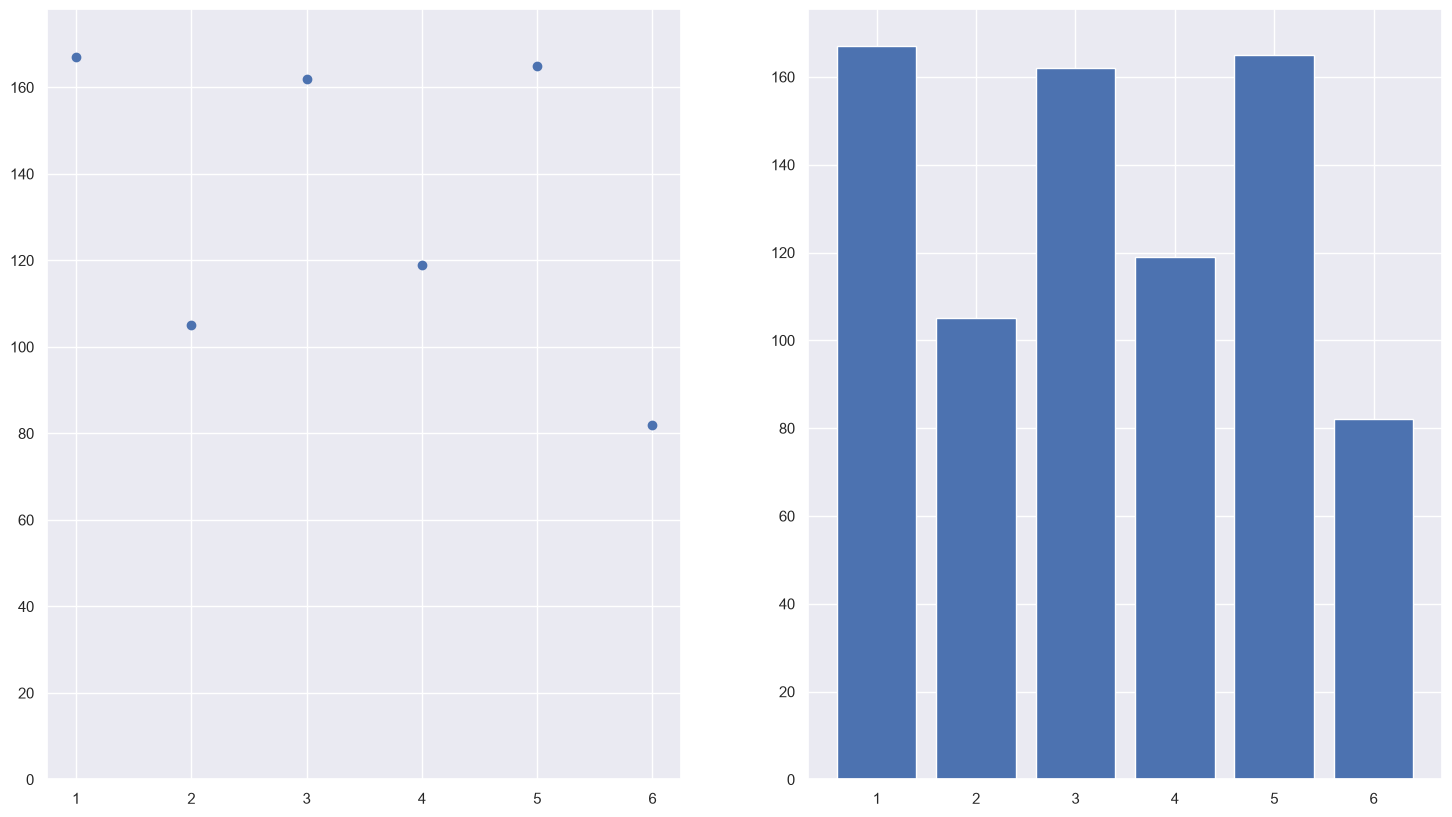

In [296]:
fig, axs = plt.subplots(1, 2, figsize=(18, 10))

x = generation
y =nbr_pokemon_par_gen

axs[0].plot(x, y, marker="o", linestyle="")
axs[0].set_ylim(0, max(y)+11)

axs[1].bar(x, y)
plt.show()

### Camembert génération / nbre légendaire

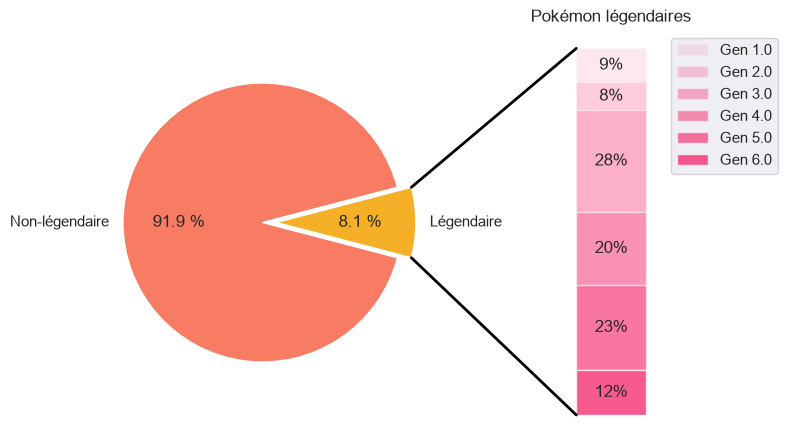

In [297]:
from matplotlib.patches import ConnectionPatch

# pie chart : légendaire vs non-légendaire (global)
overall_ratios = [total_legendaire / total_pokemon, total_non_leg / total_pokemon]
labels = ['Légendaire', 'Non-légendaire']
explode = [0.1, 0]  # on éclate la part "Légendaire"

# bar chart : répartition des légendaires par génération

ratios = legendaires_par_gen / total_legendaire
gen_labels = [f"Gen {g}" for g in generation]

# --- Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
fig.subplots_adjust(wspace=0)

# rotate so that first wedge is split by the x-axis
angle = -180 * overall_ratios[0]
pie = ax1.pie(overall_ratios, autopct='%1.1f %%', colors=['#F5B027', '#F87C63'], startangle=angle,
              labels=labels, explode=explode, #shadow=True
              )

bottom = 1
width = .2
for j, (height, label) in enumerate(#reversed
    ([*zip(ratios, gen_labels)])):
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color='#F5276C', label=label,
                 alpha=0.1 + 0.8 * j / len(ratios))
    ax2.bar_label(bc, labels=[f"{height:.0%}"], label_type='center')

ax2.set_title('Pokémon légendaires')
ax2.legend()
ax2.axis('off')
ax2.set_xlim(-2.5 * width, 2.5 * width)

# connecting lines (identique à l'exemple)
theta1, theta2 = pie.wedges[0].theta1, pie.wedges[0].theta2
center, r = pie.wedges[0].center, pie.wedges[0].r
bar_height = sum(ratios)

x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color('black')
con.set_linewidth(2)
ax2.add_artist(con)

x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color('black')
con.set_linewidth(2)
ax2.add_artist(con)

plt.show()

# inverser opcaité barre + ombre camembert // delimiter // titre

### Diagramme valeurs stats / nombre de pokémons

In [298]:
stats_cols = np.array(stats)

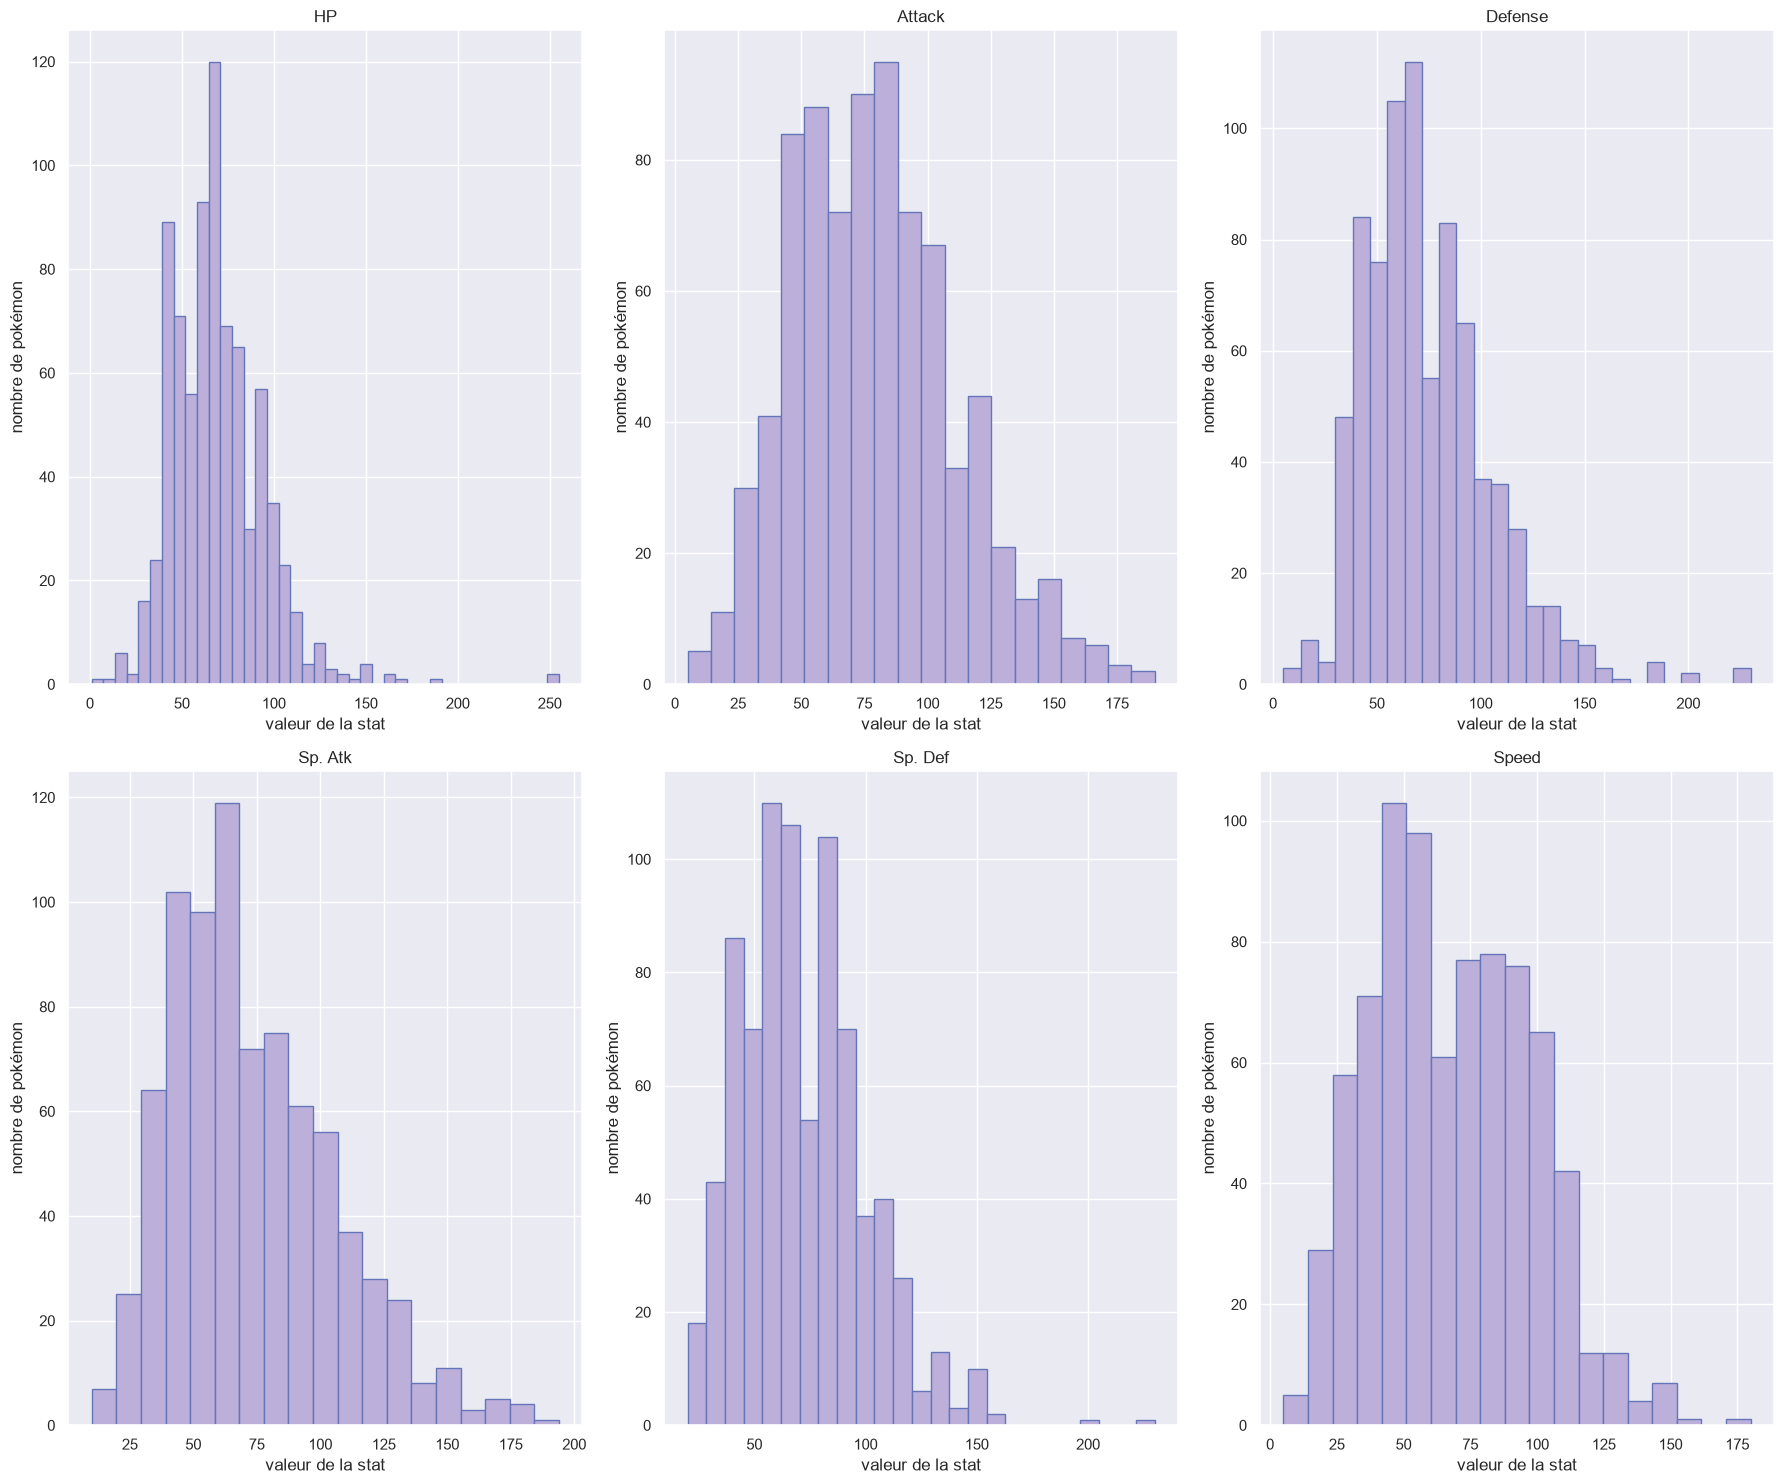

In [299]:
fig, axes = plt.subplots(2, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(stats_cols):
    axes[i].hist(df[col], color="#BCAFDA", edgecolor="#6576B8", bins="auto")
    axes[i].set_title(col)
    axes[i].set_xlabel("valeur de la stat")
    axes[i].set_ylabel("nombre de pokémon")

plt.tight_layout() # recalcule automatiquement l'espacement entre les sous-graphiques (subplots) et les marges de la figure
# = évite que les titres, labels d'axes ou légendes se chevauchent ou soient coupés = 0 impact sur les données
plt.show()

### Boîtes à stachmou des stats

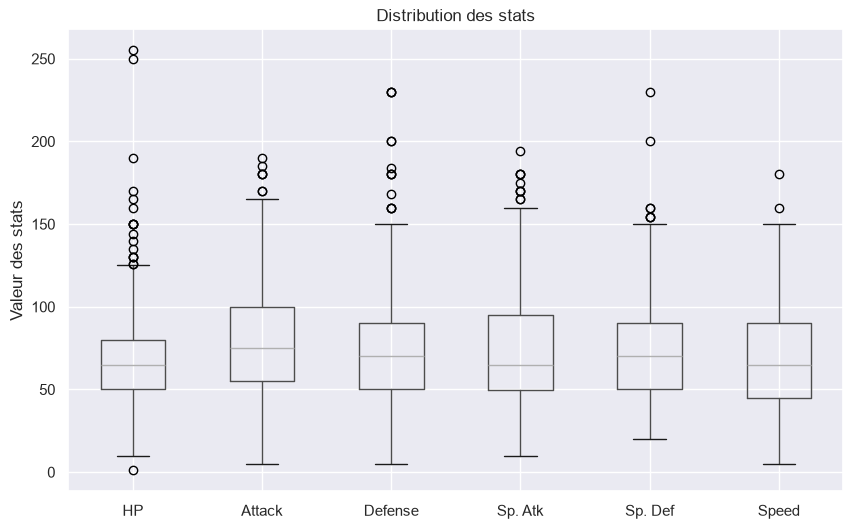

In [300]:
fig, ax = plt.subplots(figsize=(10, 6))
df[stats_cols].boxplot(ax=ax)
# boxplot() méthode pandas =rracourci qui appelle matplotlib.pyplot.boxplot() en extrayant automatiquement les colonnes du DataFrame
# evite de faire :
# data = [df[col].dropna() for col in stats_cols] # liste de tableaux, un par stat
# ax.boxplot(data, label=stats_cols.all())

ax.set_title("Distribution des stats")
ax.set_ylabel("Valeur des stats")
plt.show()

### Violins stats / legendaire ou non

#### Avec Matplotlib

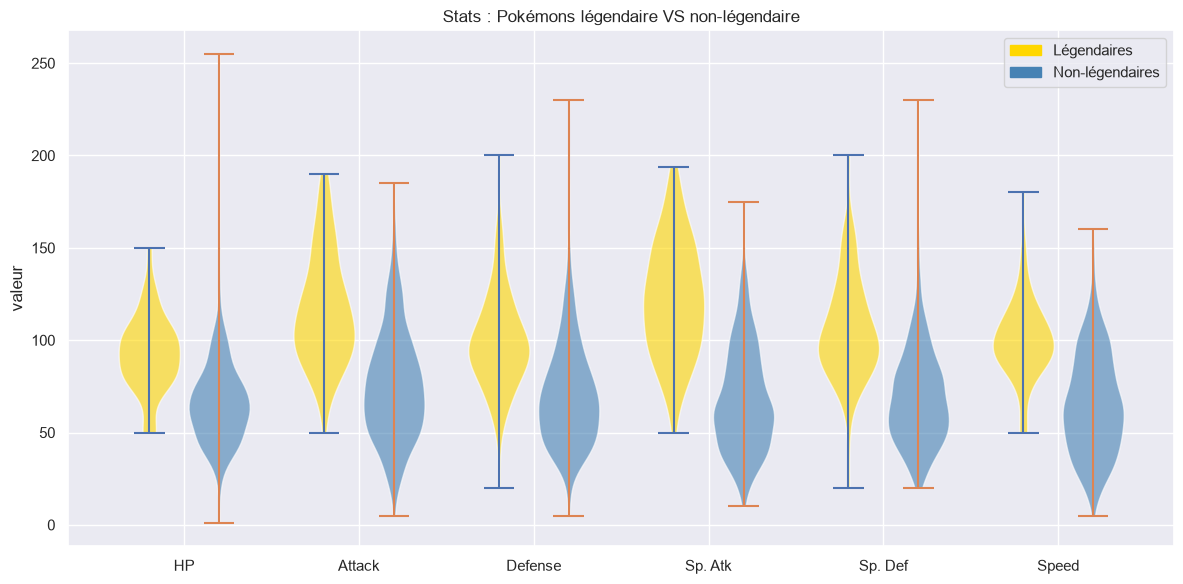

In [301]:
fig, ax = plt.subplots(figsize=(12, 6))

positions_legendaire = np.arange(len(stats_cols)) - 0.2
positions_non_legendaire = np.arange(len(stats_cols)) + 0.2

data_legendaires = [df[df["Legendary"] == "True"][col].dropna() for col in stats_cols]
data_non_legendaires = [df[df["Legendary"] == "False"][col].dropna() for col in stats_cols]

parts_legendaire = ax.violinplot(data_legendaires, positions=positions_legendaire, widths=0.35)
parts_non_legendaire = ax.violinplot(data_non_legendaires, positions=positions_non_legendaire, widths=0.35)

for pk in parts_legendaire['bodies']:
    pk.set_facecolor("gold")
    pk.set_alpha(0.6)
for pk in parts_non_legendaire['bodies']:
    pk.set_facecolor("steelblue")
    pk.set_alpha(0.6)

ax.set_xticks(np.arange(len(stats_cols)))
ax.set_xticklabels(stats_cols)
ax.set_ylabel("valeur")
ax.set_title("Stats : Pokémons légendaire VS non-légendaire")

# légende manuelle
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="gold", label="Légendaires"), Patch(color="steelblue", label="Non-légendaires")])

plt.tight_layout()
plt.show()

#### Avec Seaborn

In [302]:
import seaborn as sns
sns.set_theme() #applique theme par defaut seaborn = fond gris, taille police...
# theme applicable à tous les objets instanciés suivants même les matplotlib natifs (puisque seaborn consruit sur maplotlib et modifie params visuels de mpl)

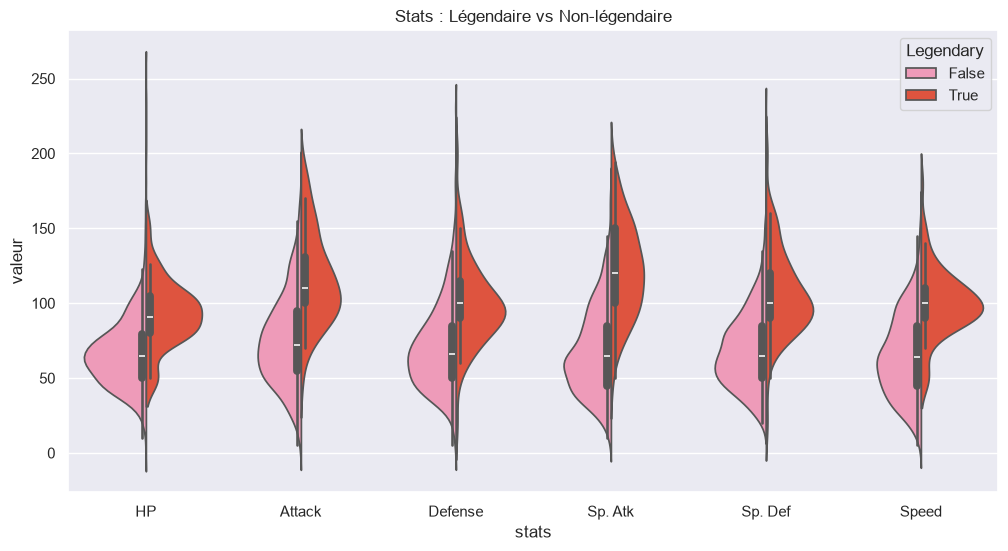

In [303]:
# transforamtion en "format long" pour pouvoir utiliser Seaborn correctement avec melt() = dépile plusieurs colonnes en une seule colonne de valeurs + une col qui indique d'où vient chaque valeur
# cf screenshot cours matplotlib section seaborn

df_long = df.melt(
    id_vars="Legendary", # colonnes a garder telles quelles (ici Legendary reste identifiable pour chaque valeur peu importe la stat)
    # = colonnes répétées pour chaque ligne générée
    value_vars=stats_cols, # colonnes à dépiler = transfomer en une lignes (ici hp, def... chaque stat)
    var_name="stats", # nom nouvelle colonne contenant nom d'origine colonne dépliée
    value_name="valeur" # nom nouvelle col qui contient les valeurs
)

# display(df.shape)
# display(df_long.shape)
# display(df.head())
# display(df_long.head())

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_long, x="stats", y="valeur", hue="Legendary", split=True, ax=ax, palette=["#FC8DB5", "#F94024"])
# hue = groupement par couleur qui evite de devoir positionner violons manuellement, côte à côte, avec mpl
ax.set_title("Stats : Légendaire vs Non-légendaire")
plt.show()

### Diagrammes types / générations

In [304]:
type1 = (df["Types"].str.split(",", expand=True))[0]
counts = df.groupby(["Generation", type1]).size().unstack(fill_value=0)
# counts --> lignes = générations, colonnes = types

#### Avec Matplotlib

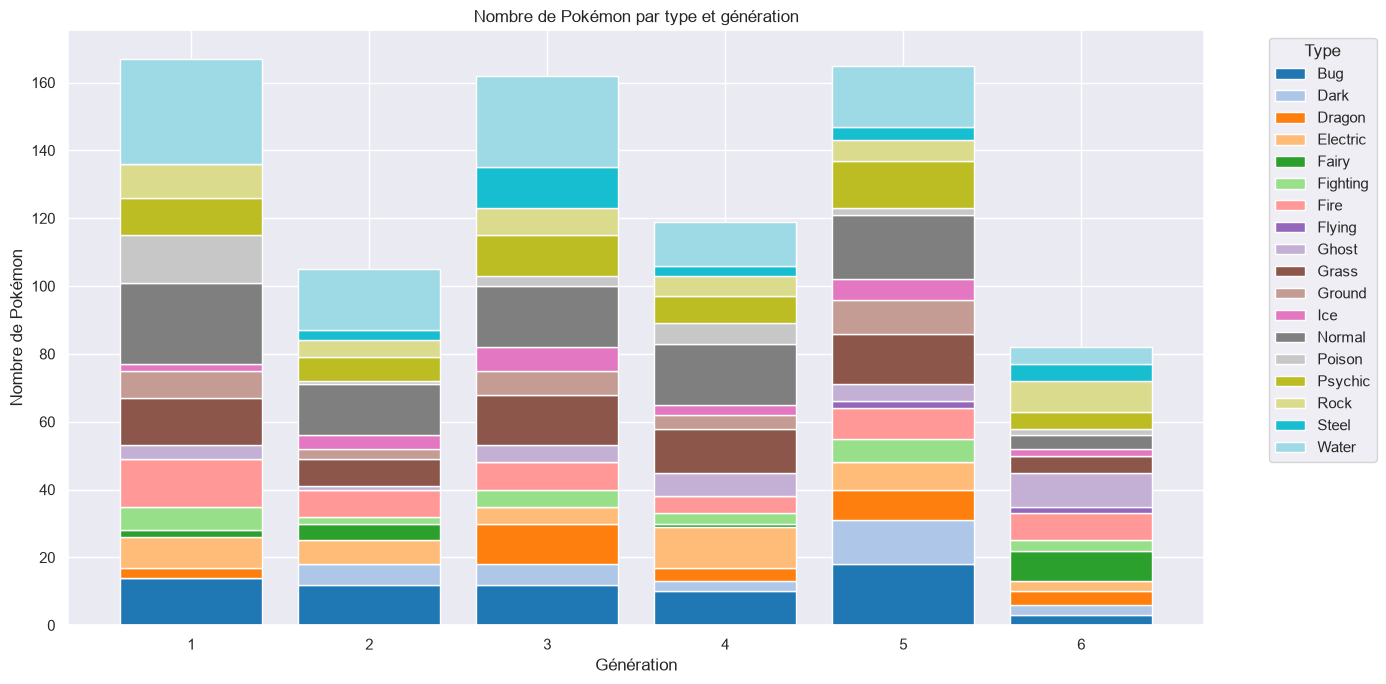

In [305]:
generations = counts.index
types = counts.columns

palette = plt.get_cmap("tab20", len(types))
colors = [palette(i) for i in range(len(types))]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(generations))

for i, t in enumerate(types):
    values = counts[t].values
    ax.bar(generations, values, bottom=bottom, color=colors[i], label=t)
    bottom += values  # on remonte le "plancher" pour la prochaine couche

ax.set_xlabel("Génération")
ax.set_ylabel("Nombre de Pokémon")
ax.set_title("Nombre de Pokémon par type et génération")
ax.legend(title="Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Avec Seaborn

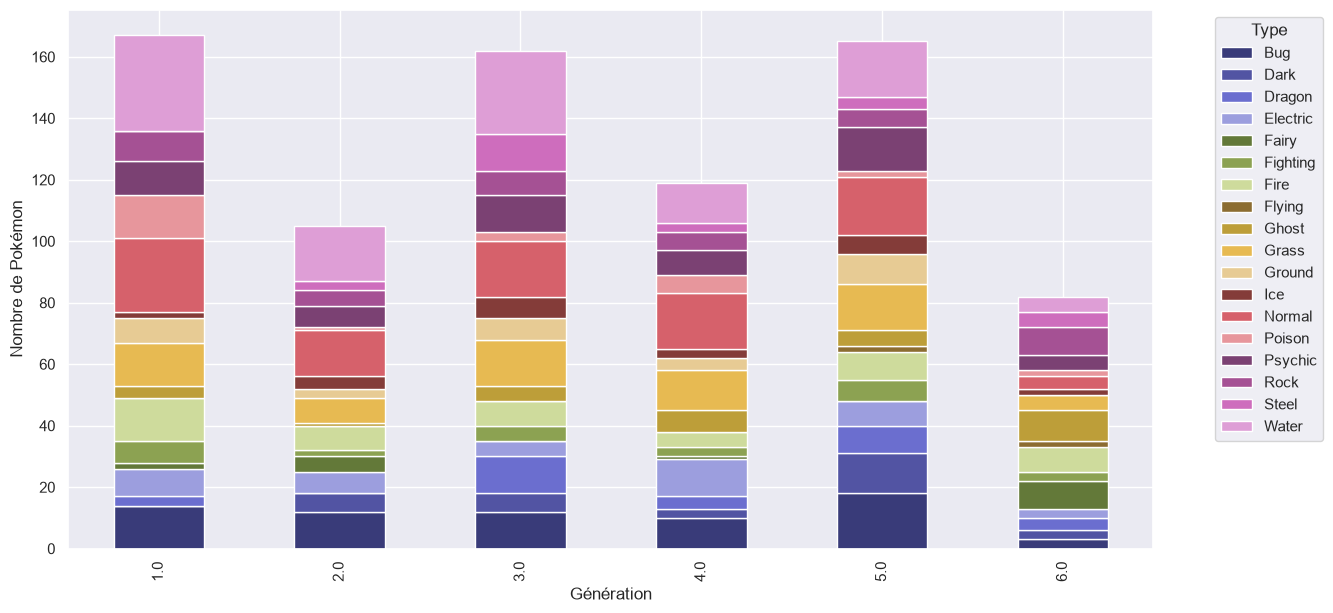

In [306]:
fig, ax = plt.subplots(figsize=(14, 7))
counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab20b")
ax.set_xlabel("Génération")
ax.set_ylabel("Nombre de Pokémon")
ax.legend(title="Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### FONCTION RADAR

In [ ]:
from typing import Mapping
from matplotlib.axes import Axes

def radar_chart(
        data: pd.DataFrame,
        entities: list[str], 
        axes: Axes,
        colors: Mapping[str, str | tuple], # tuple pour rgba 
        cols_to_plot: list[str] | np.ndarray,
        title: str,
        alpha_fill: float =0.13
        ) -> None:
    """
    data         : df indexé par une colonne (nom, type, catégorie...) = identifiant 
    entities     : liste des identifiants à tracer (doivent exister dans data.index)
    axes           : axe matplotlib (projection polaire)
    colors       : dict {identifiant: couleur}
    cols_to_plot : liste des colonnes numériques à représenter sur le radar
    title        : titre du graphique
    alpha_fill   : opacité du remplissage
    """

    angles = np.linspace(0, 2 * np.pi, len(cols_to_plot), endpoint=False).tolist()
    # angles positionne chaque stat régulièrement autour du cercle (2π divisé en 6 pour 6 stats).
    # Le += angles[:1] et row[:1] dupliquent le premier point à la fin, pour que la ligne se referme visuellement (sinon trou entre la dernière et la première stat)
    angles += angles[:1]

    
    for entity in entities:
        row = data.loc[entity, cols_to_plot].tolist()
        row += row[:1]
        color = colors.get(entity, "gray") # gris par défaut si le pokémon n'est pas dans le dico
        axes.plot(angles, row, label=entity, linewidth=2, color=color)
        axes.fill(angles, row, alpha=alpha_fill, color=color)

    axes.set_xticks(angles[:-1])
    axes.set_xticklabels(cols_to_plot)
    axes.set_title(title)
    axes.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))    

### Radars évolutions et comparaison de celles-ci

#### Données et dico couleurs

In [228]:
df_indexed = df.set_index("Name")

In [229]:
colors_evolution = {
    "Bulbasaur": "#1e5f2c",   
    "Ivysaur": "#5ba85f",    
    "Venusaur": "#9add91",   

    "Charmander": "#e8111c",  
    "Charmeleon": "#e74f25",
    "Charizard": "#f17e58", 

    "Squirtle": "#1f4e8c", 
    "Wartortle": "#5c9bd1",  
    "Blastoise": "#92c9eb", 
}

colors_comparatif = {
    "Venusaur": "#5ba85f",   
    "Charizard": "#e74f25", 
    "Blastoise": "#5c9bd1", 
}

#### En précisant bien l'indice de chaque axe

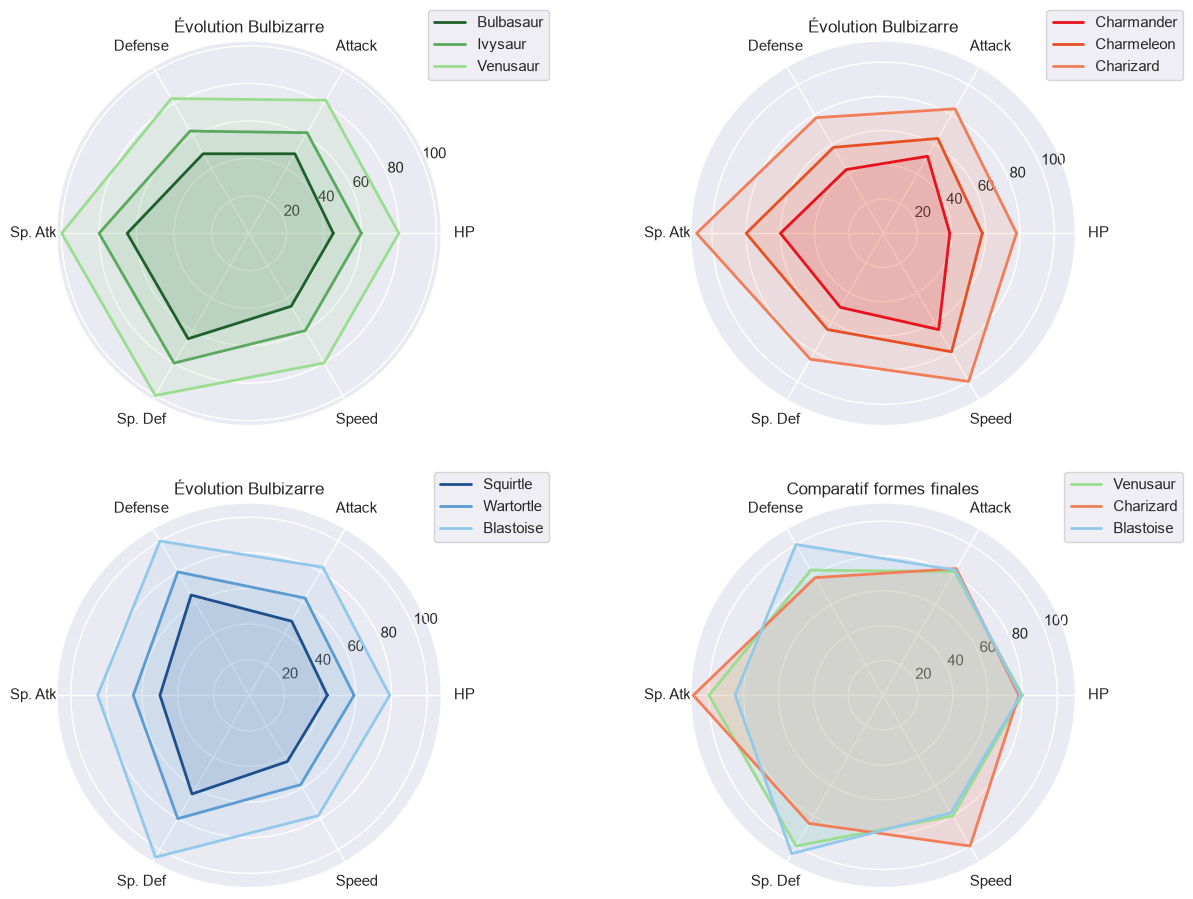

In [308]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), subplot_kw=dict(polar=True))

# ------------------ INSTANCIATION DES GRAPHS ------------------
# ------------------ 3 évolutions individuelles ------------------
radar_chart(
    data=df_indexed,
    entities=["Bulbasaur", "Ivysaur", "Venusaur"],
    axes=axes[0, 0],
    colors=colors_evolution,
    cols_to_plot=stats_cols,   
    title="Évolution Bulbizarre"
)
radar_chart(
    data=df_indexed,
    entities=["Charmander", "Charmeleon", "Charizard"],
    axes=axes[0, 1],
    colors=colors_evolution,
    cols_to_plot=stats_cols,   
    title="Évolution Bulbizarre"
)
radar_chart(
    data=df_indexed,
    entities=["Squirtle", "Wartortle", "Blastoise"],
    axes=axes[1, 0],
    colors=colors_evolution,
    cols_to_plot=stats_cols,   
    title="Évolution Bulbizarre"
)

# ------------------ comparatif des formes finales ------------------
radar_chart(
    data=df_indexed,
    entities=["Venusaur", "Charizard", "Blastoise"],
    axes=axes[1, 1],
    colors=colors_evolution,
    cols_to_plot=stats_cols,   
    title="Comparatif formes finales", 
    alpha_fill=0.17
)

#### Avec flatten(applatit array d'objets axes) et boucle pour itérer sur indices des axes

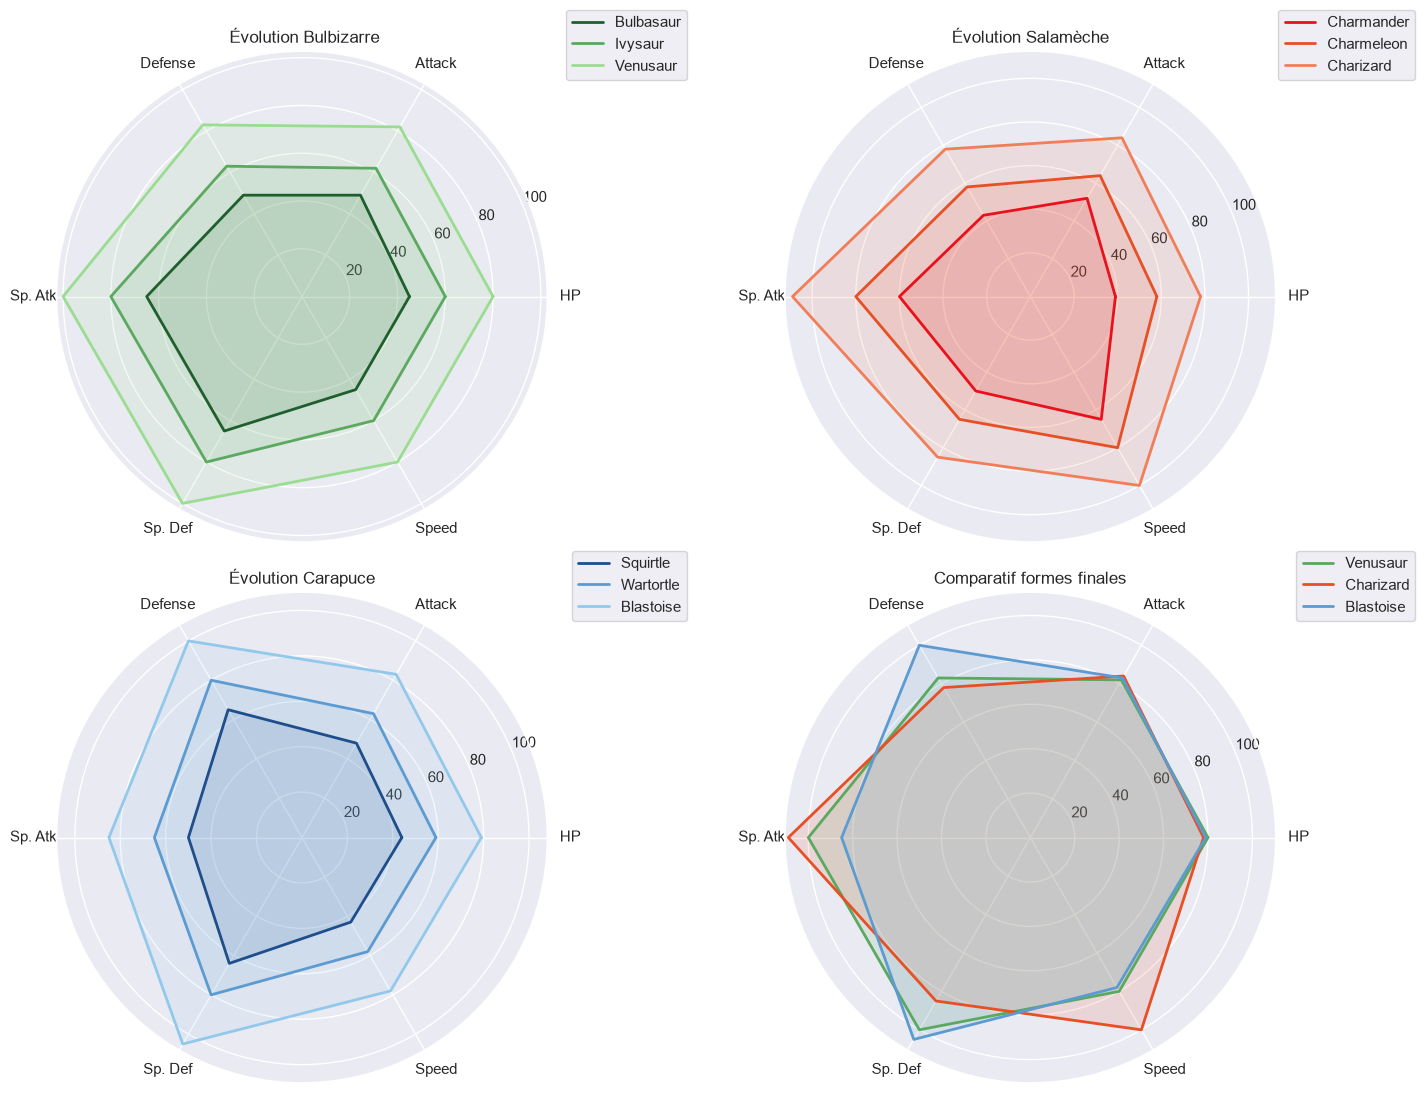

In [309]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()  # transforme le tableau 2x2 en tableau 1D de 4 éléments

configs = [
    {"entities": ["Bulbasaur", "Ivysaur", "Venusaur"], "colors": colors_evolution, "title": " Évolution Bulbizarre"},
    {"entities": ["Charmander", "Charmeleon", "Charizard"], "colors": colors_evolution, "title": "Évolution Salamèche"},
    {"entities": ["Squirtle", "Wartortle", "Blastoise"], "colors": colors_evolution, "title": "Évolution Carapuce"},
    {"entities": ["Venusaur", "Charizard", "Blastoise"], "colors": colors_comparatif, "title": "Comparatif formes finales"},
]

for ax, cfg in zip(axes_flat, configs):
    radar_chart(data=df_indexed, axes=ax, cols_to_plot=stats_cols, **cfg)

plt.tight_layout()
plt.show()

### Radar stats par type

In [316]:
means_by_type = df.groupby(type1)[stats_cols].mean()

In [ ]:
liste_types = means_by_type.index.tolist()

# dico une couleur par type sur une palette qualitative cmap
palette = plt.get_cmap("Paired", len(liste_types))
colors_types = {t: palette(i) for i, t in enumerate(liste_types)}

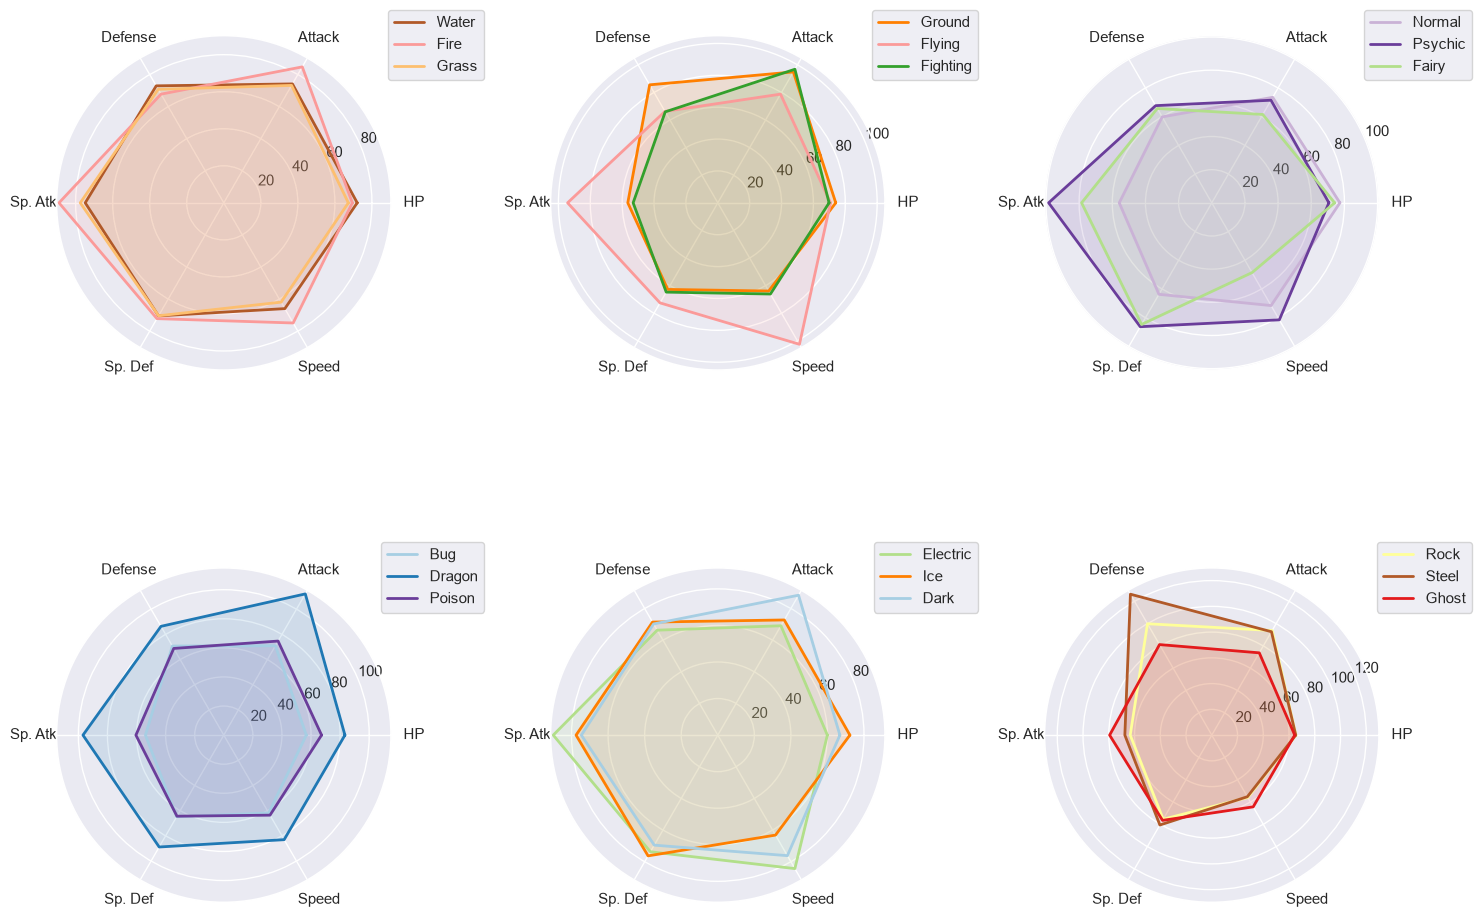

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 11), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

configs = [
    {"entities": ["Water", "Fire", "Grass"], "colors": colors_types, "title": ""},
    {"entities": ["Ground", "Flying", "Fighting"], "colors": colors_types, "title": ""},
    {"entities": ["Normal", "Psychic", "Fairy"], "colors": colors_types, "title": ""},
    {"entities": ["Bug", "Dragon", "Poison"], "colors": colors_types, "title": ""},
    {"entities": ["Electric", "Ice", "Dark"], "colors": colors_types, "title": ""},
    {"entities": ["Rock", "Steel", "Ghost"], "colors": colors_types, "title": ""},
]

for ax, cfg in zip(axes_flat, configs):
    radar_chart(data=means_by_type , axes=ax, cols_to_plot=stats_cols, **cfg)

plt.tight_layout()
plt.show()

### Nuage des types sur Attaque / Défense

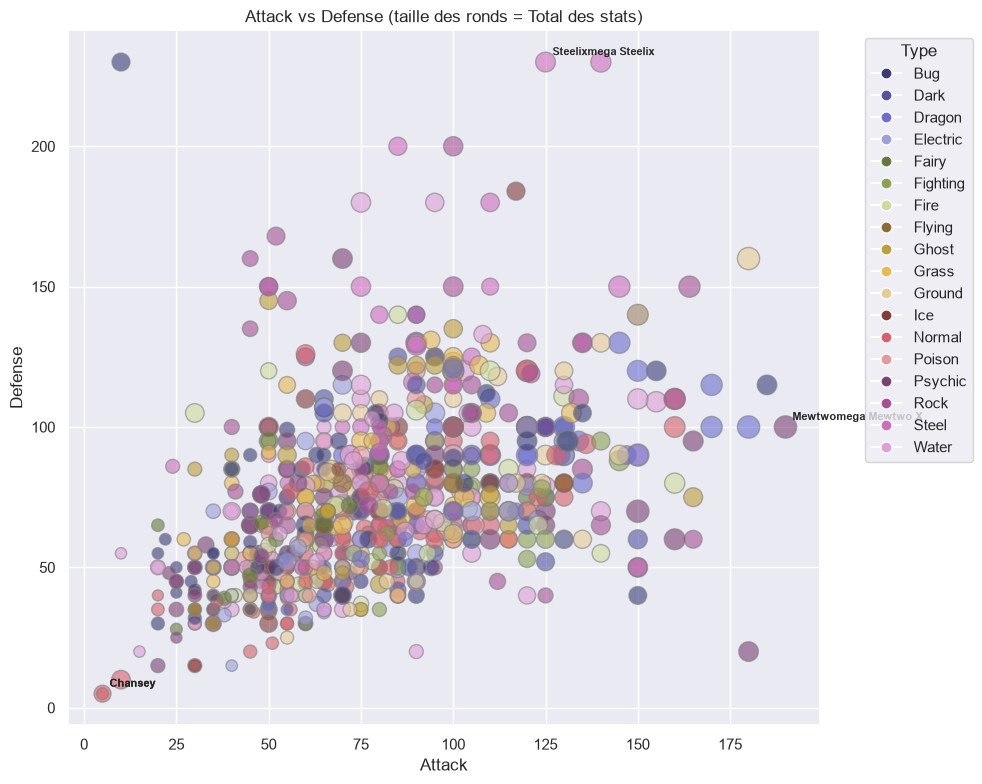

In [337]:
types = sorted(type1.unique())
palette = plt.get_cmap("tab20b", len(types))
color_map = {t: palette(i) for i, t in enumerate(types)}
colors = type1.map(color_map)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df["Attack"],
    df["Defense"],
    s=df["Total"] / 3,   # taille de bulle, divisée pour rester lisible
    c=colors,
    alpha=0.6,
    edgecolors="gray",
    linewidths=1
)

# --- Détection et annotation des outliers ---
# attack_z = (df["Attack"] - df["Attack"].mean()) / df["Attack"].std()
# defense_z = (df["Defense"] - df["Defense"].mean()) / df["Defense"].std()
# is_outlier = (attack_z.abs() > 2) | (defense_z.abs() > 2)
# outliers = df[is_outlier]

outliers = pd.concat([
    df.nlargest(1, "Defense"),
    df.nlargest(1, "Attack"),
    df.nsmallest(1, "Defense"),
    df.nsmallest(1, "Attack"),
])
for _, row in outliers.iterrows():
    ax.annotate(
        row["Name"],
        xy=(row["Attack"], row["Defense"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold"
    )
# -----------------------------------------------

ax.set_xlabel("Attack")
ax.set_ylabel("Defense")
ax.set_title("Attack vs Defense (taille des ronds = Total des stats)")

# légende manuelle (scatter ne génère pas de légende de couleur automatiquement, contrairement à seaborn qui le ferait nativement avec hue=)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[t], markersize=8, label=t) for t in types]
ax.legend(handles=handles, title="Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

index                   Name  Attack  Defense
19     Beedrillmega Beedrill   150.0     40.0
86       Slowbromega Slowbro    75.0    180.0
98                  Cloyster    95.0    180.0
103                     Onix    45.0    160.0
121                  Chansey     5.0      5.0
..                       ...     ...      ...
773                  Carbink    50.0    150.0
789                  Avalugg   117.0    184.0
795      Dianciemega Diancie   160.0    110.0
796                  Diancie   100.0    150.0
797       Hoopahoopa Unbound   160.0     60.0

[61 rows x 3 columns]
